# Component: West Antarctic Ice Sheet (WAIS)

This notebook implements the A4 deep-uncertainty framework for the WAIS
contribution to global mean sea level (GMSL). Unlike all other components
(thermosteric, glaciers, Greenland), WAIS **cannot be modeled with a
data-driven rate–temperature regression**: the observational record (28 years
of IMBIE satellite gravimetry) is too short to constrain a temperature-dependent
response for a system whose instabilities unfold over decades to centuries, and
the physics of marine ice sheet instability (MISI) involves threshold processes
poorly represented by smooth functional forms. We therefore adopt a
scenario-based approach.

---

## A4 Framework: Three-Scenario Mixture

The A4 framework constructs a probability distribution over WAIS contributions
at 2100 from a discrete mixture of physically distinct regimes. Each scenario
specifies a weight (prior probability), a 5th–95th percentile range for
cumulative SLR at 2100, a skewness parameter $\alpha$, and a trajectory
exponent $\beta$.

| Scenario | $P$ | Range (mm) | $\alpha$ | $\beta$ | Physical regime |
|----------|-----|------------|----------|---------|-----------------|
| **S1**: Status quo | 0.10 | 30–80 | 0 | 1.0 (fixed) | No MISI; current rates persist |
| **S2**: MISI | 0.80 | 150–1000 | +4 | LN(1.8, 0.3) | Marine ice sheet instability |
| **S3**: MISI + MICI | 0.10 | 600–2000 | −3 | LN(2.2, 0.3) | Ice cliff instability added |

All scenario ranges and $\beta$ priors are defined at the reference rheology
$n_{\text{ref}} = 3$ (Glen's flow law exponent used by all ISMIP6 models and
the literature that informs our bounds). A rheology correction for the
observed $n \approx 4.1$ is applied to both the endpoint and the trajectory
— see **Rheology correction** below.

The combined A4 distribution is **SSP-independent**.

---

## Scenario Justification

### S1: Status quo ($P = 0.10$; 30–80 mm)

Current discharge rates continue without MISI activation. Grounding lines
either stabilize or retreat slowly on prograde bed segments.

- **Range**: The IMBIE peak rate of ~0.44 mm/yr (Otosaka et al. 2023)
  extrapolated over 95 years gives ~42 mm. Bounds of 30–80 mm bracket
  moderate deceleration to acceleration without instability.
- **Low weight (10%)** reflects growing evidence that MISI may already be
  underway: grounding-line retreat on retrograde beds observed at Thwaites
  (Joughin et al. 2014); committed ocean thermal forcing sufficient for
  WAIS retreat regardless of emissions pathway (Naughten et al. 2023);
  present-day forcing sufficient to deglaciate large WAIS sectors
  (van den Akker et al. 2025).
- **$\alpha = 0$**: Symmetric (log-normal). No flux-geometry feedback
  operating to skew the distribution.
- **$\beta = 1.0$** (fixed): Constant rate — appropriate when MISI is not
  triggered and grounding lines remain stable.

### S2: MISI ($P = 0.80$; 150–1000 mm; $\alpha = +4$)

Marine ice sheet instability is triggered, with the full range of amplifying
processes that current models omit.

- **Lower bound (150 mm)**: Consistent with the ISMIP6 upper range for
  WAIS dynamic losses (~180 mm under RCP8.5; Seroussi et al. 2020) and
  the median total Antarctic contribution from DeConto et al. (2021)
  under ~3°C warming.
- **Upper bound (1000 mm)**: Matches the Bamber et al. (2019) structured
  expert judgment 95th percentile for WAIS under +5°C (~930 mm).
- **$\alpha = +4$** (positive skewness): Follows Robel et al. (2019),
  who showed analytically that MISI amplifies and skews uncertainty
  toward worse outcomes when the grounding-line flux nonlinearity
  exponent exceeds 3 (realistic values are 4–5). Their Thwaites
  ensemble simulations produced ~20–40 cm of irreducible uncertainty
  during rapid retreat.
- **Merges former S2/S3**: The distinction between "moderate MISI" and
  "MISI with amplifiers" is not physically defensible — if MISI is
  triggered, missing model processes (calving, subglacial hydrology
  amplifying discharge up to 3× (Dow et al. 2022), and the 21–35%
  underestimation from $n = 3$ vs. $n \approx 4$ rheology (Martin
  et al. 2026, Getraer & Morlighem 2025)) operate concurrently.
- **$\beta \sim \text{LogNormal}(\log 1.8, 0.3)$**, median 1.8
  (at $n_{\text{ref}} = 3$): See "Trajectory exponent" section below.

### S3: MISI + MICI ($P = 0.10$; 600–2000 mm; $\alpha = -3$)

Marine ice cliff instability (Bassis & Walker 2012, DeConto & Pollard
2016) operates in addition to MISI.

- **Lower bound (600 mm)**: Edwards et al. (2019) emulator for Antarctic
  SLR with MICI under RCP8.5 (~450 mm), augmented by MISI.
- **Upper bound (2000 mm)**: ~60% deglaciation of the ~3.3 m SLE WAIS
  reservoir.
- **$\alpha = -3$** (negative skewness, concentrating probability toward
  lower end): Reflects accumulating evidence against MICI viability in
  the 21st century: Morlighem et al. (2024) showed calving rates would
  need to be $\geq 25\times$ higher than physically motivated; Clerc
  et al. (2019) showed realistic shelf removal timescales raise the
  critical cliff height from ~90 m to ~540 m; Schlemm & Levermann
  (2022) found MICI self-limiting from mélange. IPCC AR6 assigns low
  confidence (Fox-Kemper et al. 2021).
- **$\beta \sim \text{LogNormal}(\log 2.2, 0.3)$**, median 2.2
  (at $n_{\text{ref}} = 3$): Stronger back-loading because MICI
  activates only after sufficient shelf removal exposes tall ice cliffs.

---

## Within-Scenario Distribution

Samples are drawn from a **skew-normal distribution in log-space**. The
parameterization has three transparent parameters:

- **Location** $\xi$ and **scale** $\omega$: determined by requiring the
  5th and 95th percentiles match the scenario bounds $(l, h)$ in log-space:

$$\omega = \frac{\log h - \log l}{z_{0.95}(\alpha) - z_{0.05}(\alpha)}, \qquad \xi = \log l - \omega\, z_{0.05}(\alpha)$$

  where $z_p(\alpha)$ is the $p$-th quantile of the standard skew-normal
  $\text{SN}(0, 1, \alpha)$.

- **Shape** $\alpha$: controls skewness. $\alpha = 0$ recovers a log-normal;
  $\alpha > 0$ produces positive skew (heavy right tail); $\alpha < 0$
  produces negative skew. This maps directly to Robel et al. (2019):
  the grounding-line flux nonlinearity ($q_g \propto h_g^{n+1}$ with
  $n > 3$) amplifies ensemble spread toward greater ice loss.

Samples are then exponentiated: $H_{2100} = \exp(X)$ where
$X \sim \text{SN}(\xi, \omega, \alpha)$.

---

## Trajectory Exponent $\beta$

The temporal distribution of mass loss within the century is governed by a
**power-law ramp** derived from grounding-line flux physics:

$$H(t) = H_{2100} \cdot R \cdot \left(\frac{t - t_0}{2100 - t_0}\right)^{\beta(n)}$$

where $R$ is the rheology endpoint correction and $\beta(n)$ depends on the
Glen's law exponent and bed geometry.

### Grounding-line flux theories: a three-framework hierarchy

The relationship between ice flux at the grounding line and the forces
resisting flow determines how mass loss accelerates as buttressing is
lost and the grounding line retreats. Three theoretical frameworks give
progressively more complete treatments of lateral confinement, and all
three inform our choice of $\beta$.

**Framework 1: Schoof (2007) — unconfined grounding-line flux.**
The boundary-layer theory for an unconfined marine ice sheet with
power-law sliding ($\tau_b = C|u|^{m-1}u$) gives:

$$q_g^{(S)} \propto h_g^{\,(m+n+3)/(m+1)}$$

When buttressing is parameterised through the backstress ratio
$\theta \in [0,1]$ (Gudmundsson et al. 2012), the flux becomes:

$$q_g^{(S)}(\theta) = q_g^{\text{unbutt}} \cdot (1 - \theta)^{s_S}, \qquad s_S = \frac{n}{m+1}$$

For $n = 3$, $m = 1/3$: $s_S = 2.25$. For $n = 4$, $m = 1/4$: $s_S = 3.2$.

**Limitation:** Schoof (2007) assumes no lateral confinement. ASE glaciers
(PIG, TWG) flow through laterally confined embayments where shear-margin
drag provides the dominant buttressing mechanism.

**Framework 2: Pegler (2018) — confined shelf with lateral drag.**
Pegler extends the flux theory to laterally confined ice shelves where
viscous lateral drag dominates buttressing. The backstress scales as
$\sigma_{\text{back}} \propto B(L_s/W)^{1/n} h_s^{(n+1)/n}$, where the
extra thickness dependence arises from the depth-integrated viscosity.
The resulting flux condition is:

$$q_g^{(P)}(\theta) = q_g^{\text{unbutt}} \cdot (1 - \theta)^{s_P}, \qquad s_P = \frac{n+1}{m+1}$$

For $n = 3$, $m = 1/3$: $s_P = 3.0$. For $n = 4$, $m = 1/4$: $s_P = 4.0$.

The confined exponent exceeds the unconfined one by $1/(m+1)$: lateral
drag depends on ice thickness through the Glen-law viscosity, so thinner
ice transmits less lateral stress — an effect amplified by shear-thinning
($n > 1$). **This is the appropriate baseline for ASE glaciers.**

**Framework 3: Haseloff & Sergienko (2018, 2022) — resolved shear margins.**
Resolving the shear-margin structure (rather than assuming plug flow)
introduces a velocity-dependent correction from the nonlinear coupling
between centreline velocity and margin stress:

$$s_H \approx \frac{n+1}{m+1} + \frac{1}{n} = s_P + \frac{1}{n}$$

For $n = 4$: $s_H \approx 4.25$. For $n = 3$: $s_H \approx 3.33$.

The Haseloff correction is 6–11% above the Pegler exponent — a Phase 2
refinement.

**Summary table:**

| Framework | Exponent formula | $s(n{=}3, m{=}1/3)$ | $s(n{=}4, m{=}1/4)$ | Ratio $s(n{=}4)/s(n{=}3)$ |
|-----------|-----------------|---------------------|---------------------|---------------------------|
| Schoof (unconfined) | $n/(m+1)$ | 2.25 | 3.20 | 1.42 |
| Pegler (confined) | $(n+1)/(m+1)$ | 3.00 | 4.00 | 1.33 |
| Haseloff (resolved margins) | $(n+1)/(m+1) + 1/n$ | 3.33 | 4.25 | 1.28 |

### From flux exponent to trajectory exponent $\beta$

The flux exponent $s$ governs the *instantaneous* sensitivity of discharge
to buttressing state. The *cumulative* trajectory exponent $\beta$ governs
how mass loss accumulates over time as the system evolves.

**Derivation.** On a retrograde bed with uniform slope $\alpha_b$, the
flotation condition gives $h_g \approx h_0 + \alpha_b x$, where $x$ is
retreat distance. Mass conservation at the grounding line gives the retreat
rate:

$$\frac{dx}{dt} \sim \frac{q_g}{h_g} \propto h_g^{\,n} \propto (h_0 + \alpha_b x)^n$$

Assuming $x(t) \propto (t - t_0)^\gamma$ during the acceleration phase and
matching exponents: $\gamma - 1 = n\gamma$, giving $\gamma = 1/(1-n)$.
For $n > 1$, $\gamma < 0$ — finite-time blowup reflecting the genuine MISI
instability. In practice, retreat is regularised by bed topography (prograde
segments, pinning points), buttressing, and finite ice supply.

The cumulative mass loss integrates the flux:
$H(t) \propto \int q_g\, dt' \propto (t - t_0)^{\gamma(n+1) + 1}$, giving
the idealised trajectory exponent $\beta_{\text{ideal}} = 2/(1-n)$ — negative
for $n > 1$, reflecting the singularity. The regularised system produces a
bounded trajectory with an **effective** $\beta > 1$ that inherits its
dependence on $n$ from the flux condition.

### Scaling of $\beta$ with $n$: robust across all three frameworks

The key result is that the **ratio** of trajectory exponents when correcting
from $n_{\text{ref}}$ to $n$ is the same for all three frameworks:

$$\frac{\beta(n)}{\beta(n_{\text{ref}})} = \frac{s(n)}{s(n_{\text{ref}})}$$

Computing this ratio for each framework:

- **Schoof:** $s(n)/s(n_{\text{ref}}) = [n/(m+1)] / [n_{\text{ref}}/(m+1)] = n/n_{\text{ref}}$
- **Pegler:** $s(n)/s(n_{\text{ref}}) = [(n+1)/(m+1)] / [(n_{\text{ref}}+1)/(m+1)] = (n+1)/(n_{\text{ref}}+1)$
- **Haseloff:** $s(n)/s(n_{\text{ref}}) = [(n+1)/(m+1) + 1/n] / [(n_{\text{ref}}+1)/(m+1) + 1/n_{\text{ref}}]$

In all cases, the sliding-law exponent $m$ either cancels entirely (Schoof,
Pegler) or nearly cancels (Haseloff, where the $1/n$ correction is small).
This is a significant result: **the $\beta$ correction for rheology is
insensitive to the poorly constrained sliding law**, depending only on $n$
(which is well-observed).

We adopt the Pegler ratio as the baseline because it is the physically
appropriate framework for confined ASE glaciers:

$$\boxed{\beta(n) = \beta_{\text{ref}} \cdot \frac{n + 1}{n_{\text{ref}} + 1}}$$

Note that the Schoof (unconfined) ratio $n/n_{\text{ref}}$ gives a slightly
larger correction (1.33 vs 1.25 for $n=4, n_{\text{ref}}=3$), so the Pegler
result is the more conservative choice.

### Scenario-dependent values

The $\beta_{\text{ref}}$ values (defined at $n_{\text{ref}} = 3$) are:

- **S1** ($\beta = 1.0$, fixed): No MISI $\Rightarrow$ no flux-geometry
  feedback $\Rightarrow$ constant rate $\Rightarrow$ linear ramp.
- **S2** ($\beta_{\text{ref}} \sim \text{LN}(\log 1.8, 0.3)$, median 1.8):
  MISI active; back-loaded trajectory. Spread reflects bed geometry
  uncertainty across WAIS drainage basins.
- **S3** ($\beta_{\text{ref}} \sim \text{LN}(\log 2.2, 0.3)$, median 2.2):
  MISI + MICI; stronger back-loading because MICI is inherently late-stage.

After rheology correction with $n = 4.1 \pm 0.4$ (Millstein et al. 2022):

| Scenario | $\beta_{\text{ref}}$ (median, $n=3$) | $\beta(n=4.1)$ (median) | Scaling factor |
|----------|--------------------------------------|-------------------------|----------------|
| S1 | 1.0 | 1.0 (no correction) | — |
| S2 | 1.8 | 2.3 | 1.275 |
| S3 | 2.2 | 2.8 | 1.275 |

### Self-consistency of $\alpha$, $\beta$, $R$, and $s$

All four quantities derive from the same confined flux condition
$q_g \propto (1 - \theta_{\text{ref}} \beta)^s$ with $s = (n+1)/(m+1)$
(Pegler 2018):

- **$\alpha$** (endpoint skewness): the flux nonlinearity amplifies
  **cross-ensemble** uncertainty toward worse outcomes (Robel et al. 2019).
- **$\beta$** (trajectory exponent): the flux nonlinearity concentrates
  **within-trajectory** mass loss toward the end of the century.
- **$R$** (endpoint correction): corrects the **magnitude** for the
  systematic $n = 3$ bias in current models.
- **$s$** (flux-buttressing exponent): the theoretical prediction from
  confined grounding-line flux theory that underpins all three.

A framework that includes any subset but neglects the others is internally
inconsistent — they are four manifestations of the same physics.

### Observational cross-checks

- **Bamber et al. (2019) SEJ**: Experts placed only ~22% of WAIS loss
  before 2050. For S2 with corrected $\beta(n=4.1) = 2.3$:
  predicted 2050 fraction = $(45/95)^{2.3} \approx 0.18$, consistent.
- **IMBIE satellite era**: The observed WAIS trajectory (1992–2020) can
  be fit with a power law to estimate $\beta_{\text{obs}}$. Values near
  1.0 are consistent with either S1 or early-stage MISI.

---

## Rheology Correction: Two Options

All ISMIP6-class models use Glen's flow law exponent $n = 3$, but satellite
observations yield $n = 4.1 \pm 0.4$ (Millstein et al. 2022), supported by
field measurements (Bons et al. 2018), laboratory meta-analysis (Fan et al.
2025), and a theoretical framework connecting laboratory to ice-sheet scales
(Ranganathan et al. 2024). This mismatch affects both the **endpoint** (total
SLR at 2100) and the **trajectory** (how mass loss is distributed in time),
because both depend on $(n+1)$ through the Schoof flux condition.

We implement two options; set `RHEOLOGY_MODE = 'A'` or `'B'` in the
configuration cell below.

### Option A: Independent corrections (default)

Scenario ranges and $\beta$ priors are defined at $n_{\text{ref}} = 3$
(matching the ISMIP6 / Bamber / DeConto literature). Two separate
corrections are applied per MC sample:

1. **Endpoint**: $R \sim \mathcal{N}(1.28, 0.07^2)$, truncated $\geq 1$.
   The median 1.28 spans the MISMIP+ result (1.21; Martin et al. 2026) to
   the ABUMIP result (1.35; Getraer & Morlighem 2025).
2. **Trajectory**: $\beta_{\text{corrected}} = \beta_{n=3} \cdot (n_{\text{draw}} + 1) / (n_{\text{ref}} + 1)$,
   where $n_{\text{draw}} \sim \mathcal{N}(4.1, 0.4^2)$ is drawn independently.

**Pros:** Traceability — scenario ranges correspond directly to published
values. Corrections are explicit, auditable steps. $R$ is calibrated to
specific model intercomparisons.

**Cons:** $R$ and the $\beta$ correction are drawn independently, so they are
uncorrelated despite both depending on $n$. This is conservative (wider
combined uncertainty) but not fully self-consistent.

### Option B: Unified $n$-driven corrections

A single draw of $n$ per sample drives both endpoint and trajectory
corrections, ensuring physical correlation:

1. $n_{\text{draw}} \sim \mathcal{N}(4.1, 0.4^2)$, clipped $\geq n_{\text{ref}}$.
2. **Endpoint**: $R(n) = 1 + r_0 \cdot (n_{\text{draw}} - n_{\text{ref}})$,
   where $r_0 \approx 0.28$ (Martin et al. 2026: 28% per unit $\Delta n$).
3. **Trajectory**: $\beta(n) = \beta_{\text{ref}} \cdot (n_{\text{draw}} + 1) / (n_{\text{ref}} + 1)$.

A sample with high $n$ gets both a larger endpoint correction and a more
back-loaded trajectory — physically correct because both effects originate
from the same flux nonlinearity.

**Pros:** Single uncertainty source ($n$) drives all corrections coherently.
No risk of inconsistent endpoint and trajectory corrections. Every
consequence traces to one observable quantity.

**Cons:** $R(n)$ is a linearization of the Martin et al. result, which was
computed at discrete $n$ values. The linear approximation is adequate for
$n \in [3, 5]$ but has not been validated beyond this range.

### Comparison

For both options, the marginal distributions of $R$ and $\beta$ are similar.
The difference is in their **joint distribution**: Option A produces
uncorrelated ($R$, $\beta$) pairs, while Option B correlates them through $n$.
The practical effect on the mixture distribution at 2100 is small because the
scenario weight uncertainty (S1/S2/S3 split) dominates; the difference is most
visible in the temporal *shape* of the projection fan at intermediate years
(2040–2070).

---

## SSP Independence

The combined A4 distribution is SSP-independent. WAIS dynamics on projection
timescales are driven primarily by subsurface ocean thermal forcing with long
lag times (~decades), not by contemporaneous surface atmospheric warming.
Naughten et al. (2023) showed that rapid West Antarctic ice-shelf melting at
~3× historical rates is unavoidable regardless of emissions scenario through
at least 2100.

---

## Observations

- **IMBIE West Antarctica** (Otosaka et al. 2023): 1992–2020, monthly,
  cumulative ~6.6 mm SLE. Structural break at ~2010: acceleration
  0.015 mm/yr² (1992–2010), deceleration −0.031 mm/yr² (2010–2020).
  Peak rate ~0.44 mm/yr around 2010–2012.
- **Bamber et al. (2019) SEJ**: Independent cross-check on A4 mixture.
  Under +5°C, WAIS 5th–95th percentile: −50 to 930 mm (median 180 mm).

---

## Implementation

- `sample_a4_wais(n_samples, rng, year, rheology_mode='A')` in
  `notebooks/component_projections.py`
- Set `RHEOLOGY_MODE = 'A'` or `'B'` in the configuration cell below.
- `_sample_log_skewnormal()` for within-scenario sampling
- `A4_SCENARIOS` dict: weights, bounds, $\alpha$, $\beta$ params
- Constants:
  - `RHEOLOGY_FACTOR_MEDIAN = 1.28`, `RHEOLOGY_FACTOR_SIGMA = 0.07` (Mode A)
  - `N_OBS_MEAN = 4.1`, `N_OBS_SIGMA = 0.4`, `N_REF = 3` (Mode B)
  - `RHEOLOGY_SENSITIVITY = 0.28` (Mode B, $r_0$)
  - `BASELINE_YEAR = 2005.0`

---

## References

- Bamber, Oppenheimer, Kopp, Aspinall, & Cooke (2019). Ice sheet contributions to future sea-level rise from structured expert judgment. *PNAS* 116, 11195–11200.
- Bassis & Walker (2012). Upper and lower limits on the stability of calving glaciers from the yield strength envelope of ice. *Proc. R. Soc. A* 468, 913–931.
- Bons et al. (2018). Greenland Ice Sheet: higher nonlinearity of ice flow significantly reduces estimated basal motion. *GRL* 45, 6542–6548.
- Clerc, Minchew, & Behn (2019). Marine ice cliff instability mitigated by slow removal of ice shelves. *GRL* 46, 12108–12116.
- DeConto & Pollard (2016). Contribution of Antarctica to past and future sea-level rise. *Nature* 531, 591–597.
- DeConto et al. (2021). The Paris Climate Agreement and future sea-level rise from Antarctica. *Nature* 593, 83–89.
- Dow et al. (2022). Basal channels drive active surface hydrology and transverse ice shelf fracture. *Science Advances* 8, eabn3537.
- Edwards et al. (2019). Revisiting Antarctic ice loss due to marine ice-cliff instability. *Nature* 566, 58–64.
- Fan et al. (2025). A meta-analysis of ice creep experiments. *JGR Solid Earth*.
- Fox-Kemper et al. (2021). Ocean, cryosphere and sea level change. In *IPCC AR6 WGI*, Ch. 9.
- Getraer & Morlighem (2025). Higher Glen's flow law exponent increases Amundsen Sea Embayment contribution to SLR. *GRL*.
- Joughin, Smith, & Medley (2014). Marine ice sheet collapse potentially under way for the Thwaites Glacier Basin, West Antarctica. *Science* 344, 735–738.
- Martin, Minchew, & Mitrovica (2026). Underestimation of sea-level rise projections from ice-sheet models with incorrect ice rheology. *AGU Advances*.
- Millstein, Minchew, & Goldberg (2022). Ice viscosity is more sensitive to stress than commonly assumed. *Communications Earth & Environment* 3, 57.
- Morlighem et al. (2024). The West Antarctic ice sheet may not be vulnerable to marine ice cliff instability during the 21st century. *Science Advances* 10, eado7794.
- Naughten et al. (2023). Unavoidable future increase in West Antarctic ice-shelf melting over the twenty-first century. *Nature Climate Change* 13, 1222–1228.
- Otosaka et al. (2023). Mass balance of the Greenland and Antarctic ice sheets from 1992 to 2020. *Earth System Science Data* 15, 1597–1616.
- Ranganathan et al. (2024). A new framework for estimating ice rheology from laboratory to ice-sheet scales. *JGR Earth Surface*.
- Robel, Seroussi, & Roe (2019). Marine ice sheet instability amplifies and skews uncertainty in projections of future sea-level rise. *PNAS* 116, 14887–14892.
- Schlemm & Levermann (2022). A simple parametrization of mélange buttressing for calving glaciers. *The Cryosphere* 16, 1979–1996.
- Schoof (2007). Ice sheet grounding line dynamics: steady states, stability, and hysteresis. *JGR Earth Surface* 112, F03S28.
- Schoof (2012). Marine ice sheet stability. *J. Fluid Mech.* 698, 62–72.
- Seroussi et al. (2020). ISMIP6 Antarctica: a multi-model ensemble of the Antarctic ice sheet evolution over the 21st century. *The Cryosphere* 14, 3033–3070.
- van den Akker et al. (2025). Present-day forcing is sufficient for large-scale retreat of the West Antarctic ice sheet. *Nature Geoscience*.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-poster')

sys.path.insert(0, '.')
from slr_data_readers import read_imbie_west_antarctica
from component_analysis import annualize_imbie
from component_projections import (
    sample_a4_wais, A4_SCENARIOS, RHEOLOGY_FACTOR_MEDIAN,
    RHEOLOGY_FACTOR_SIGMA, _sample_log_skewnormal,
    N_OBS_MEAN, N_OBS_SIGMA, N_REF, RHEOLOGY_SENSITIVITY,
    read_ipcc_component_nc, ipcc_extract,
)
from component_plotting import (
    SSP_COLORS, COMP_COLORS, M_TO_MM,
    plot_component_projection_twopanel,
    plot_component_histogram,
    plot_component_ridge,
)

H5_PATH = '../data/processed/slr_processed_data.h5'
RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'

BASELINE_YEAR = 2005.0
N_SAMPLES = 2000

# ── Rheology mode ──
# 'A': Independent corrections (endpoint R drawn separately from β correction)
# 'B': Unified n-driven corrections (single n draw drives both R and β)
RHEOLOGY_MODE = 'A'

## 1. Data Loading

In [2]:
df_wais = read_imbie_west_antarctica(f'{RAW_DIR}/ice_sheets/antarctica/imbie_west_antarctica_2021_mm.csv')
wais_year, wais_rebase, wais_sigma = annualize_imbie(df_wais, baseline_year=BASELINE_YEAR)

print(f'WAIS IMBIE: {wais_year[0]:.0f}–{wais_year[-1]:.0f}, {len(wais_year)} points')
print(f'WAIS cumulative at end: {wais_rebase[-1]*M_TO_MM:.1f} mm')

WAIS IMBIE: 1992–2020, 29 points
WAIS cumulative at end: 0.0 mm


## 2. A4 Framework

### Scenario structure

| Scenario | P | 2100 range (mm) | α | Physics |
|----------|---|-----------------|---|---------|
| S1: Status quo | 10% | 30–80 | 0 | Current discharge rates continue; no MISI |
| S2: MISI | 80% | 150–1000 | +4 | Marine ice sheet instability with amplification |
| S3: MISI+MICI | 10% | 600–2000 | −3 | Full instability cascade including ice cliff failure |

### Distribution
- Skew-normal in log-space: 5th/95th percentiles anchored to low/high bounds; α controls skewness
- S2 positive skew (Robel et al. 2019): MISI amplifies worst-case outcomes
- S3 negative skew: skepticism that MICI operates at maximum efficiency (Morlighem et al. 2024)

### Corrections applied
- **A1 Rheology**: n=3→n=4 correction (Martin et al. 2026), factor 1.28 ± 0.07, applied to all scenarios

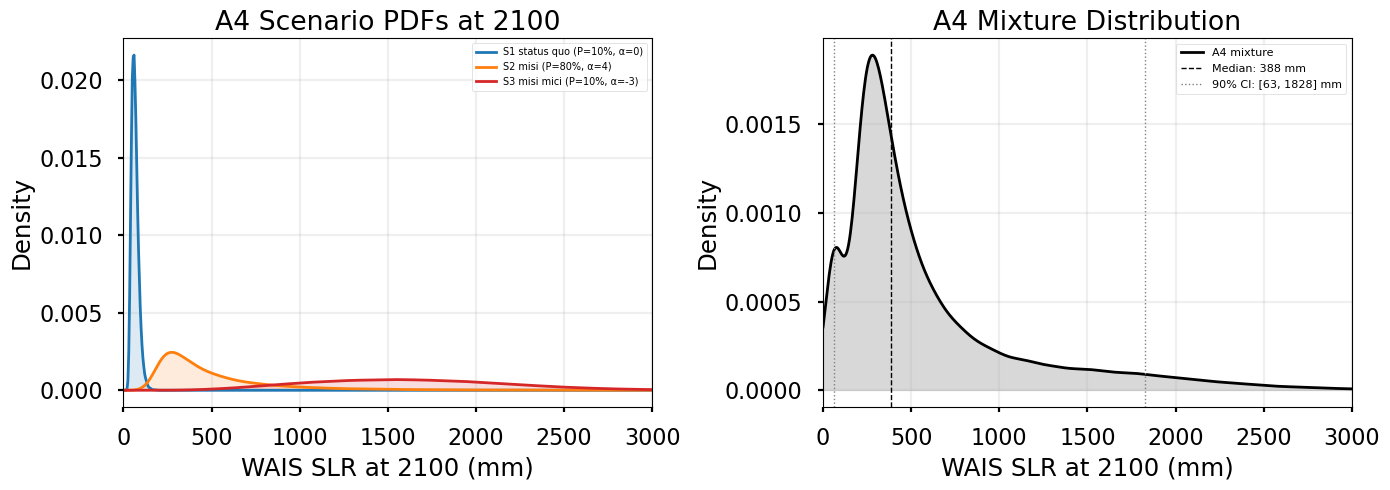

In [3]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Per-scenario PDFs at 2100
ax = axes[0]
x_grid = np.linspace(0, 3000, 600)
scenario_colors = {'S1_status_quo': 'C0', 'S2_misi': 'C1', 'S3_misi_mici': 'C3'}

for sname, params in A4_SCENARIOS.items():
    s_rng = np.random.default_rng(hash(sname) % 2**31)
    # Draw from per-scenario distribution (before rheology)
    base = _sample_log_skewnormal(
        200000, params['low_mm'], params['high_mm'], params['alpha'], s_rng,
    )
    # Apply rheology correction
    rheo = s_rng.normal(RHEOLOGY_FACTOR_MEDIAN, RHEOLOGY_FACTOR_SIGMA, 200000)
    rheo = np.maximum(rheo, 1.0)
    base *= rheo

    kde = gaussian_kde(base, bw_method='scott')
    label = f'{sname.replace("_", " ")} (P={params["P"]:.0%}, α={params["alpha"]:.0f})'
    ax.plot(x_grid, kde(x_grid), lw=2, color=scenario_colors[sname], label=label)
    ax.fill_between(x_grid, kde(x_grid), alpha=0.15, color=scenario_colors[sname])

ax.set_xlabel('WAIS SLR at 2100 (mm)')
ax.set_ylabel('Density')
ax.set_title('A4 Scenario PDFs at 2100')
ax.legend(fontsize=7)
ax.set_xlim(0, 3000)
ax.grid(True, alpha=0.2)

# Panel B: Mixture distribution
ax = axes[1]
mixture = sample_a4_wais(200000, np.random.default_rng(99), year=2100, rheology_mode=RHEOLOGY_MODE)
kde_mix = gaussian_kde(mixture, bw_method='scott')
ax.plot(x_grid, kde_mix(x_grid), 'k-', lw=2, label='A4 mixture')
ax.fill_between(x_grid, kde_mix(x_grid), alpha=0.3, color='gray')
ax.axvline(np.median(mixture), color='k', ls='--', lw=1, label=f'Median: {np.median(mixture):.0f} mm')
p5, p95 = np.percentile(mixture, [5, 95])
ax.axvline(p5, color='gray', ls=':', lw=1)
ax.axvline(p95, color='gray', ls=':', lw=1, label=f'90% CI: [{p5:.0f}, {p95:.0f}] mm')
ax.set_xlabel('WAIS SLR at 2100 (mm)')
ax.set_ylabel('Density')
ax.set_title('A4 Mixture Distribution')
ax.legend(fontsize=8)
ax.set_xlim(0, 3000)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_wais_a4_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

if False:
    print(f'A4 mixture at 2100: median={np.median(mixture):.0f} mm, '
          f'mean={np.mean(mixture):.0f} mm, '
          f'[5th, 95th] = [{p5:.0f}, {p95:.0f}] mm')
    skew = float(np.mean(((mixture - np.mean(mixture)) / np.std(mixture))**3))
    print(f'Skewness: {skew:.2f}')

## 3. Diagnostics & Validation

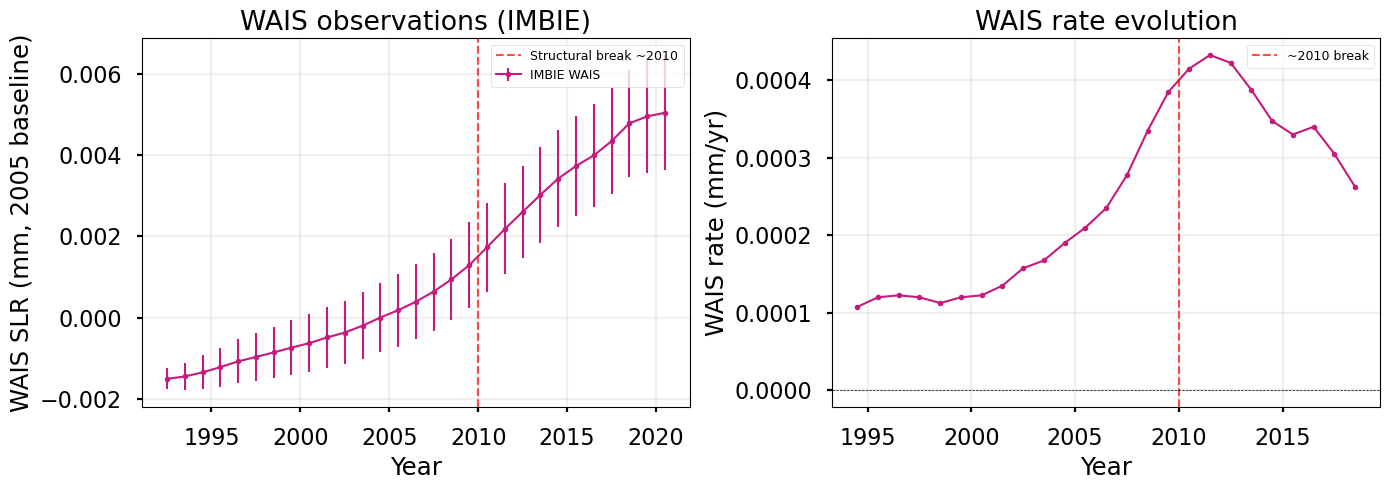

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: IMBIE time series
ax = axes[0]
ax.errorbar(wais_year, wais_rebase * M_TO_MM, yerr=2*wais_sigma*M_TO_MM,
            fmt='o-', ms=4, color=COMP_COLORS['WAIS'], lw=1.5, label='IMBIE WAIS')
ax.axvline(2010, color='red', ls='--', lw=1.5, alpha=0.7, label='Structural break ~2010')
ax.set_xlabel('Year')
ax.set_ylabel('WAIS SLR (mm, 2005 baseline)')
ax.set_title('WAIS observations (IMBIE)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Panel B: Rate evolution
ax = axes[1]
from component_analysis import compute_component_rates
rates = compute_component_rates(wais_year, wais_rebase, window=2) * M_TO_MM
valid = np.isfinite(rates)
ax.plot(wais_year[valid], rates[valid], 'o-', ms=4, color=COMP_COLORS['WAIS'], lw=1.5)
ax.axvline(2010, color='red', ls='--', lw=1.5, alpha=0.7, label='~2010 break')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Year')
ax.set_ylabel('WAIS rate (mm/yr)')
ax.set_title('WAIS rate evolution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_wais_observations.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Projections

In [5]:
PROJ_YEARS = np.arange(1950, 2151, dtype=float)
PROJ_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
rng_wais = np.random.default_rng(2026)

# A4 is SSP-independent — same samples for all SSPs
wais_samples_mm = np.zeros((N_SAMPLES, len(PROJ_YEARS)))
for j, yr in enumerate(PROJ_YEARS):
    if yr <= BASELINE_YEAR:
        continue  # zero before baseline
    wais_samples_mm[:, j] = sample_a4_wais(N_SAMPLES, rng_wais, year=yr, rheology_mode=RHEOLOGY_MODE)

wais_samples_m = wais_samples_mm / M_TO_MM

# Build projection dict (same for all SSPs)
wais_proj = {}
for ssp in PROJ_SSPS:
    wais_proj[ssp] = {
        'samples': wais_samples_m,
        'median': np.median(wais_samples_m, axis=0),
        'p5': np.percentile(wais_samples_m, 5, axis=0),
        'p95': np.percentile(wais_samples_m, 95, axis=0),
        'p17': np.percentile(wais_samples_m, 17, axis=0),
        'p83': np.percentile(wais_samples_m, 83, axis=0),
    }

idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
med = np.median(wais_samples_mm[:, idx_2100])
p5 = np.percentile(wais_samples_mm[:, idx_2100], 5)
p95 = np.percentile(wais_samples_mm[:, idx_2100], 95)
print(f'WAIS at 2100 (A4): {med:.0f} [{p5:.0f}, {p95:.0f}] mm (SSP-independent)')

WAIS at 2100 (A4): 397 [67, 1919] mm (SSP-independent)


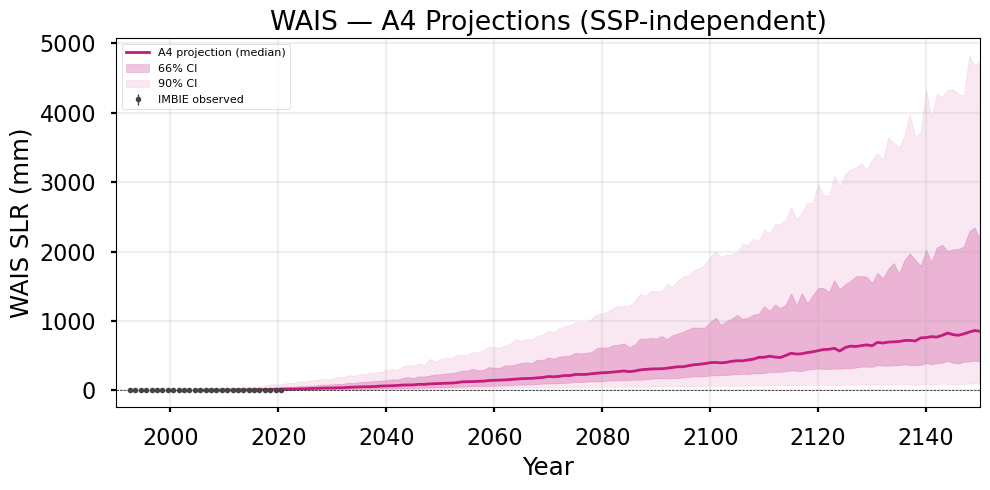

In [6]:
# WAIS has no temperature dependence — show obs + forward projection
# Upper: WAIS A4 projections with IMBIE obs
# Lower: omit temperature (not applicable)

fig, ax = plt.subplots(figsize=(10, 5))

# Observations
ax.errorbar(wais_year, wais_rebase * M_TO_MM, yerr=2*wais_sigma*M_TO_MM,
            fmt='o', ms=4, color='#444444', lw=1, label='IMBIE observed', zorder=5)

# Projections (SSP-independent, show as single fan)
proj_mask = PROJ_YEARS >= BASELINE_YEAR
yr_plot = PROJ_YEARS[proj_mask]
p = wais_proj['SSP2-4.5']
ax.plot(yr_plot, p['median'][proj_mask] * M_TO_MM, color=COMP_COLORS['WAIS'], lw=2,
        label='A4 projection (median)')
ax.fill_between(yr_plot, p['p17'][proj_mask]*M_TO_MM, p['p83'][proj_mask]*M_TO_MM,
                color=COMP_COLORS['WAIS'], alpha=0.25, label='66% CI')
ax.fill_between(yr_plot, p['p5'][proj_mask]*M_TO_MM, p['p95'][proj_mask]*M_TO_MM,
                color=COMP_COLORS['WAIS'], alpha=0.10, label='90% CI')

ax.set_xlabel('Year')
ax.set_ylabel('WAIS SLR (mm)')
ax.set_title('WAIS — A4 Projections (SSP-independent)')
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(1990, 2150)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_wais_projection.png', dpi=150, bbox_inches='tight')
plt.show()

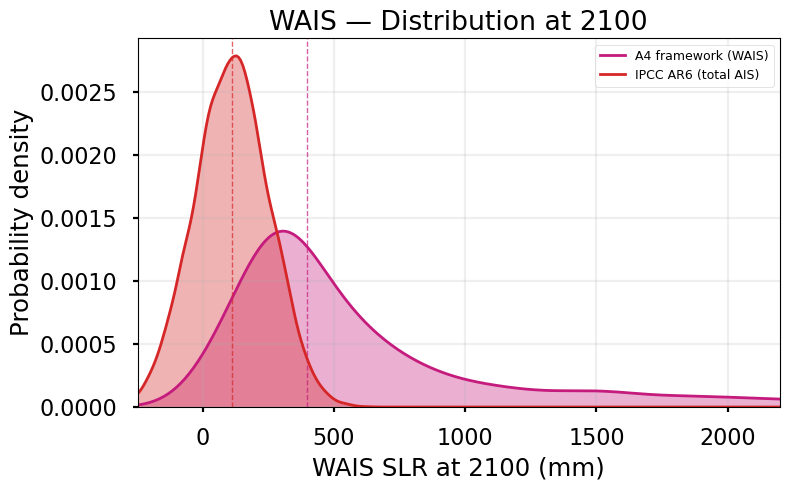

In [7]:
rng_hist = np.random.default_rng(99)
our_samples = wais_samples_mm[:, idx_2100]

SSP_CODE = {'SSP2-4.5': 'ssp245'}
ipcc_data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', 'ssp245', 'AIS')
sample_sets = [our_samples]
labels = ['A4 framework (WAIS)']
colors = [COMP_COLORS['WAIS']]
if ipcc_data is not None:
    ex = ipcc_extract(ipcc_data)
    yr_idx = np.argmin(np.abs(ex['years'] - 2100))
    ipcc_med = ex['q50'][yr_idx]
    ipcc_sig = (ex['q95'][yr_idx] - ex['q05'][yr_idx]) / (2 * 1.645)
    ipcc_samples = rng_hist.normal(ipcc_med, ipcc_sig, 10000)
    sample_sets.append(ipcc_samples)
    labels.append('IPCC AR6 (total AIS)')
    colors.append('tab:red')

plot_component_histogram(sample_sets, labels, colors, 'WAIS', year=2100,
                          save_path=f'{FIG_DIR}/component_wais_histogram_2100.png')

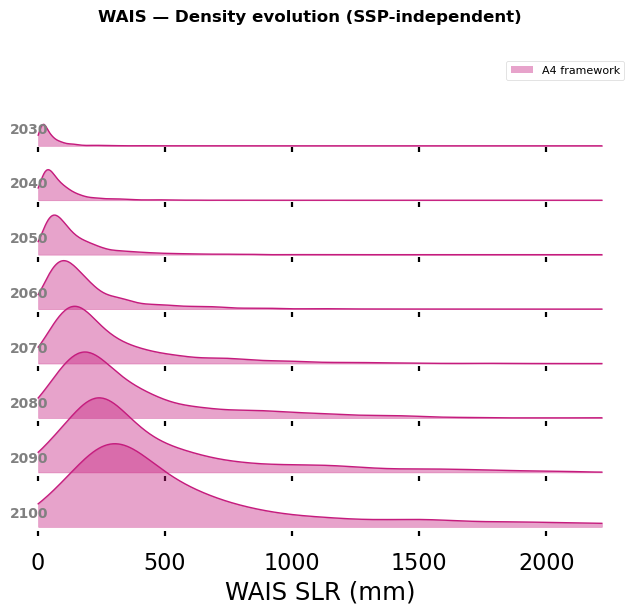

In [8]:
RIDGE_YEARS = list(range(2030, 2110, 10))
rng_ridge = np.random.default_rng(202)

samples_by_year = {}
for yr in RIDGE_YEARS:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    samples_by_year[yr] = {'A4 framework': wais_samples_mm[:, idx_yr]}

plot_component_ridge(samples_by_year, 'WAIS', 'SSP-independent',
                      source_colors={'A4 framework': COMP_COLORS['WAIS']},
                      save_path=f'{FIG_DIR}/component_wais_ridge.png')

## 5. IPCC Comparison

The IPCC AR6 AIS component combines EAIS + Peninsula + WAIS. Our A4 framework
produces wider uncertainty ranges than the IPCC medium-confidence AIS, reflecting
the deep uncertainty in marine ice sheet instability that process models
(ISMIP6) may underestimate.

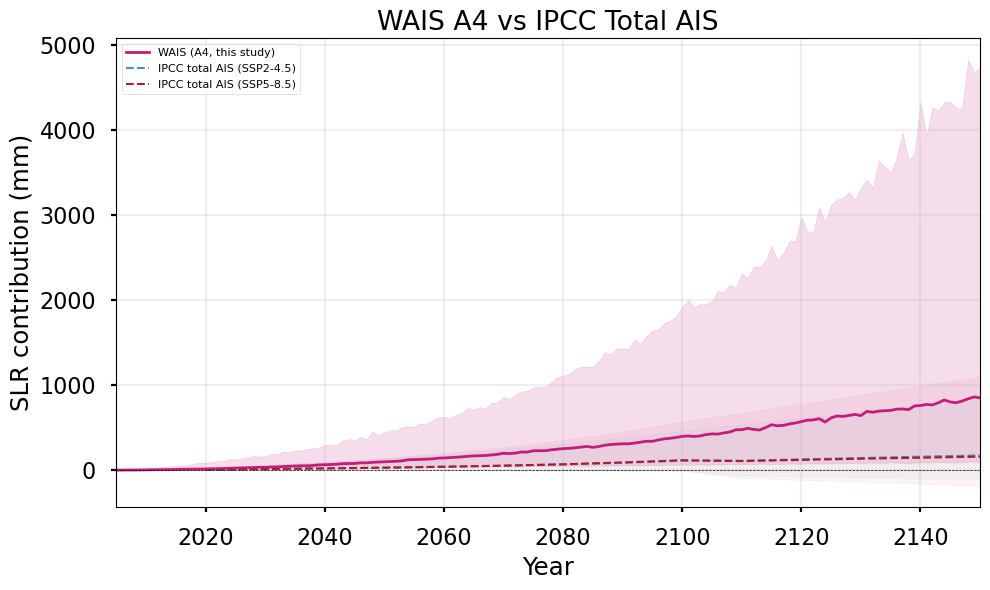

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
proj_mask = PROJ_YEARS >= 2005
yr_plot = PROJ_YEARS[proj_mask]

# Our WAIS
p = wais_proj['SSP2-4.5']
ax.plot(yr_plot, p['median'][proj_mask]*M_TO_MM, color=COMP_COLORS['WAIS'], lw=2,
        label='WAIS (A4, this study)')
ax.fill_between(yr_plot, p['p5'][proj_mask]*M_TO_MM, p['p95'][proj_mask]*M_TO_MM,
                color=COMP_COLORS['WAIS'], alpha=0.15)

# IPCC total AIS
for ssp, ssp_code in [('SSP2-4.5', 'ssp245'), ('SSP5-8.5', 'ssp585')]:
    ipcc = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', ssp_code, 'AIS')
    if ipcc is not None:
        ex = ipcc_extract(ipcc)
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(ex['years'], ex['q50'], color=color, ls='--', lw=1.5,
                label=f'IPCC total AIS ({ssp})')
        ax.fill_between(ex['years'], ex['q05'], ex['q95'], color=color, alpha=0.05)

ax.set_xlabel('Year')
ax.set_ylabel('SLR contribution (mm)')
ax.set_title('WAIS A4 vs IPCC Total AIS')
ax.legend(fontsize=8)
ax.set_xlim(2005, 2150)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_wais_ipcc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Appendix: Sensitivity & Reviewer Q&A

### Scenario weight sensitivity
### Range sensitivity
### Rheology exponent sensitivity

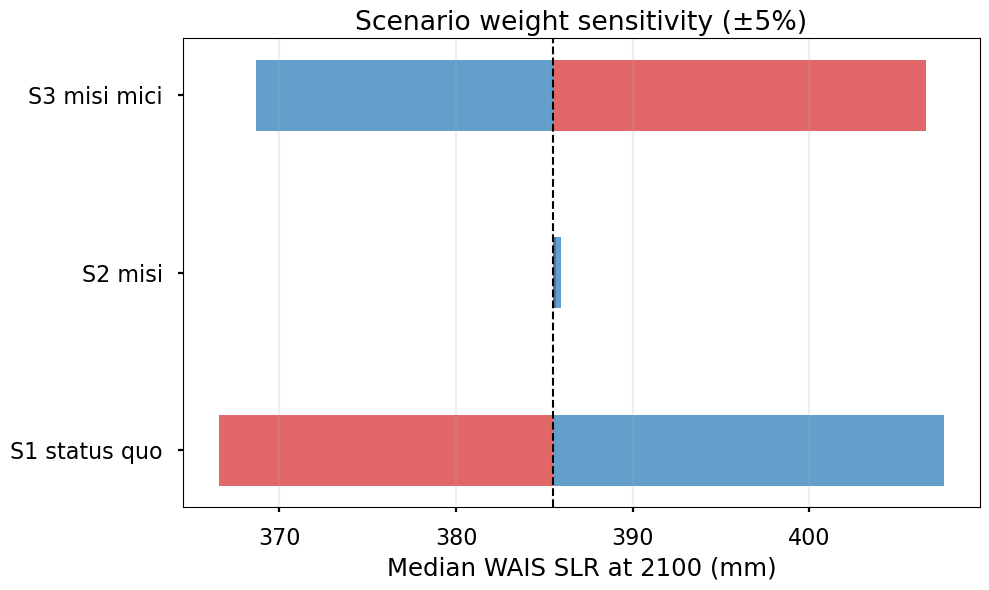

In [10]:
# ── Tornado diagram: perturb each scenario weight by ±0.05 ──
perturbation = 0.05

fig, ax = plt.subplots(figsize=(10, 6))

base_med = np.median(sample_a4_wais(100000, np.random.default_rng(1), year=2100, rheology_mode=RHEOLOGY_MODE))

scenarios = list(A4_SCENARIOS.keys())
y_pos = np.arange(len(scenarios))
med_lo, med_hi = [], []

for i, sname in enumerate(scenarios):
    orig_p = A4_SCENARIOS[sname]['P']
    orig_remaining = 1.0 - orig_p

    for direction, storage in [('hi', med_hi), ('lo', med_lo)]:
        if direction == 'hi':
            new_p = min(orig_p + perturbation, 0.95)
            seed = 42 + i
        else:
            new_p = max(orig_p - perturbation, 0.01)
            seed = 142 + i

        remaining = 1.0 - new_p
        probs_mod = []
        for s2 in scenarios:
            if s2 == sname:
                probs_mod.append(new_p)
            else:
                probs_mod.append(A4_SCENARIOS[s2]['P'] * remaining / orig_remaining)

        rng_mod = np.random.default_rng(seed)
        samples_mod = np.zeros(100000)
        scenario_idx = rng_mod.choice(len(scenarios), size=100000, p=probs_mod)
        for k, s2 in enumerate(scenarios):
            mask = scenario_idx == k
            n_s = mask.sum()
            if n_s == 0:
                continue
            s = A4_SCENARIOS[s2]
            base_s = _sample_log_skewnormal(
                n_s, s['low_mm'], s['high_mm'], s['alpha'], rng_mod,
            )
            rheo = rng_mod.normal(RHEOLOGY_FACTOR_MEDIAN, RHEOLOGY_FACTOR_SIGMA, n_s)
            rheo = np.maximum(rheo, 1.0)
            base_s *= rheo
            samples_mod[mask] = base_s
        storage.append(np.median(samples_mod))

# Tornado
for i, sname in enumerate(scenarios):
    ax.barh(y_pos[i], med_hi[i] - base_med, left=base_med, height=0.4,
            color='C3', alpha=0.7)
    ax.barh(y_pos[i], med_lo[i] - base_med, left=base_med, height=0.4,
            color='C0', alpha=0.7)

ax.axvline(base_med, color='k', ls='--', lw=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels([s.replace('_', ' ') for s in scenarios])
ax.set_xlabel('Median WAIS SLR at 2100 (mm)')
ax.set_title(f'Scenario weight sensitivity (±{perturbation:.0%})')
ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_wais_tornado.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── Range sensitivity: ±20% on (low, high) bounds ──
scenarios = list(A4_SCENARIOS.keys())
probs = [A4_SCENARIOS[s]['P'] for s in scenarios]

print('Range sensitivity (±20% on bounds):')
for factor_label, range_factor in [('-20%', 0.8), ('Base', 1.0), ('+20%', 1.2)]:
    rng_rs = np.random.default_rng(77)
    samples_rs = np.zeros(100000)
    scenario_idx = rng_rs.choice(len(scenarios), size=100000, p=probs)
    for k, sname in enumerate(scenarios):
        mask = scenario_idx == k
        n_s = mask.sum()
        if n_s == 0:
            continue
        s = A4_SCENARIOS[sname]
        base_s = _sample_log_skewnormal(
            n_s, s['low_mm'] * range_factor, s['high_mm'] * range_factor,
            s['alpha'], rng_rs,
        )
        rheo = rng_rs.normal(RHEOLOGY_FACTOR_MEDIAN, RHEOLOGY_FACTOR_SIGMA, n_s)
        rheo = np.maximum(rheo, 1.0)
        base_s *= rheo
        samples_rs[mask] = base_s
    p5, med, p95 = np.percentile(samples_rs, [5, 50, 95])
    print(f'  {factor_label}: median={med:.0f} [{p5:.0f}, {p95:.0f}] mm')

# ── Rheology exponent sensitivity ──
print('\nRheology exponent sensitivity:')
for n_exp, rheo_med in [(3.5, 1.14), (4.0, 1.28), (4.5, 1.44)]:
    rng_rh = np.random.default_rng(88)
    samples_rh = np.zeros(100000)
    scenario_idx = rng_rh.choice(len(scenarios), size=100000, p=probs)
    for k, sname in enumerate(scenarios):
        mask = scenario_idx == k
        n_s = mask.sum()
        if n_s == 0:
            continue
        s = A4_SCENARIOS[sname]
        base_s = _sample_log_skewnormal(
            n_s, s['low_mm'], s['high_mm'], s['alpha'], rng_rh,
        )
        rheo = rng_rh.normal(rheo_med, RHEOLOGY_FACTOR_SIGMA, n_s)
        rheo = np.maximum(rheo, 1.0)
        base_s *= rheo
        samples_rh[mask] = base_s
    p5, med, p95 = np.percentile(samples_rh, [5, 50, 95])
    print(f'  n={n_exp}: rheology factor={rheo_med:.2f}, '
          f'median={med:.0f} [{p5:.0f}, {p95:.0f}] mm')

# ── Skewness sensitivity ──
print('\nSkewness (alpha) sensitivity for S2:')
for alpha_test in [0, 2, 4, 6]:
    rng_sk = np.random.default_rng(55)
    samples_sk = np.zeros(100000)
    scenario_idx = rng_sk.choice(len(scenarios), size=100000, p=probs)
    for k, sname in enumerate(scenarios):
        mask = scenario_idx == k
        n_s = mask.sum()
        if n_s == 0:
            continue
        s = A4_SCENARIOS[sname]
        alpha_use = alpha_test if sname == 'S2_misi' else s['alpha']
        base_s = _sample_log_skewnormal(
            n_s, s['low_mm'], s['high_mm'], alpha_use, rng_sk,
        )
        rheo = rng_sk.normal(RHEOLOGY_FACTOR_MEDIAN, RHEOLOGY_FACTOR_SIGMA, n_s)
        rheo = np.maximum(rheo, 1.0)
        base_s *= rheo
        samples_sk[mask] = base_s
    p5, med, p95 = np.percentile(samples_sk, [5, 50, 95])
    print(f'  alpha={alpha_test}: median={med:.0f} [{p5:.0f}, {p95:.0f}] mm')

Range sensitivity (±20% on bounds):
  -20%: median=310 [50, 1472] mm
  Base: median=387 [63, 1840] mm
  +20%: median=465 [75, 2209] mm

Rheology exponent sensitivity:
  n=3.5: rheology factor=1.14, median=343 [55, 1615] mm
  n=4.0: rheology factor=1.28, median=385 [62, 1812] mm
  n=4.5: rheology factor=1.44, median=434 [70, 2039] mm

Skewness (alpha) sensitivity for S2:
  alpha=0: median=498 [63, 1756] mm
  alpha=2: median=437 [63, 1798] mm
  alpha=4: median=388 [63, 1819] mm
  alpha=6: median=371 [63, 1825] mm


In [12]:
# ══════════════════════════════════════════════════════════════════
# §6  Export results to HDF5
# ══════════════════════════════════════════════════════════════════
from component_io import save_wais

save_wais(
    a4_scenarios=A4_SCENARIOS,
    obs_years=wais_year,
    obs_H=wais_rebase,
    obs_sigma=wais_sigma,
    wais_proj=wais_proj,
    rheology_factor_median=RHEOLOGY_FACTOR_MEDIAN,
    rheology_factor_sigma=RHEOLOGY_FACTOR_SIGMA,
)

Saved wais → /Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/data/processed/component_results.h5  (242870 KB total)
